# 05 Bayesian Update

This notebook combines three information sources into a final posterior probability for the next FOMC decision:

1. a market-implied prior from CME FedWatch when available, otherwise a documented fallback prior
2. a calibrated likelihood from `04_construct_calibrated_likelihood_layer.ipynb`
3. dynamic weighting based on meeting proximity and regime-specific model accuracy

## Pipeline Position

This is the final aggregation step. It consumes the calibrated likelihood from notebook 04,
the regime-specific accuracy export from notebook 03.2, and the current realtime regime from
03.1 outputs, then writes `bayesian_output.csv` for the final forecast table.

The output is a normalized posterior distribution over:
- Lower
- Same
- Higher

In [1]:
import json
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from IPython.display import display

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

LABEL_MAP = {-1: 0, 0: 1, 1: 2}
INV_LABEL_MAP = {0: -1, 1: 0, 2: 1}
CLASS_ORDER = ['Lower', 'Same', 'Higher']
CLASS_TO_INDEX = {'Lower': 0, 'Same': 1, 'Higher': 2}
INITIAL_TRAIN_SIZE = 40

NOTEBOOK_ROOT = Path.cwd().resolve()
if str(NOTEBOOK_ROOT.parent) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_ROOT.parent))

from modeling.notebook_io import infer_project_root

PROJECT_ROOT = infer_project_root(NOTEBOOK_ROOT)
print(f'Working directory: {NOTEBOOK_ROOT.resolve()}')
print(f'Project root     : {PROJECT_ROOT}')


Working directory: /Users/echohuang/Documents/forecasting_fed_rate/analysis
Project root     : /Users/echohuang/Documents/forecasting_fed_rate


## 1. Load calibration data and the latest walk-forward model output

This section loads:
- the decile calibration map exported from `04_construct_calibrated_likelihood_layer.ipynb`
- the cached walk-forward probability outputs from the same likelihood-layer workflow

XGBoost is used as the primary model when available.
If XGBoost is unavailable, the notebook falls back to the average probability vector across all available boosting models.

In [2]:
def resolve_existing_path(*candidates, required=True):
    search_roots = [NOTEBOOK_ROOT, PROJECT_ROOT, PROJECT_ROOT / 'analysis', PROJECT_ROOT / 'data']
    seen = set()

    for candidate in candidates:
        candidate_path = Path(candidate)
        expanded = [candidate_path]
        if not candidate_path.is_absolute():
            expanded.extend(root / candidate_path for root in search_roots)

        for path in expanded:
            resolved = path.resolve()
            if resolved in seen:
                continue
            seen.add(resolved)
            if resolved.exists():
                return resolved

    if required:
        raise FileNotFoundError(f'None of the candidate paths exist: {candidates}')
    return None


cache_path = resolve_existing_path(
    'final_results_cache.pkl',
    'data/final_results_cache.pkl',
    'analysis/final_results_cache.pkl',
)
df_model_path = resolve_existing_path(
    'data/df_model.csv',
    'df_model.csv',
    'analysis/df_model.csv',
)
calibration_path = resolve_existing_path(
    'calibration_map.csv',
    'data/calibration_map.csv',
    'analysis/calibration_map.csv',
)

model_cache = pd.read_pickle(cache_path)
final_results = model_cache['final_results']
df_model = pd.read_csv(df_model_path, parse_dates=['meeting_date'])
calibration_map = pd.read_csv(calibration_path)

available_models = list(final_results.keys())
print(f'Calibration map: {calibration_path.resolve()}')
print(f'Model cache     : {cache_path.resolve()}')
print(f'Available models: {available_models}')

if 'XGBoost' in final_results:
    selected_model = 'XGBoost'
    latest_model_probs = np.asarray(final_results['XGBoost']['probas'][-1], dtype=float)
    likelihood_source = 'XGBoost'
else:
    selected_model = 'Ensemble'
    prob_stack = np.stack([np.asarray(final_results[name]['probas'][-1], dtype=float) for name in available_models])
    latest_model_probs = prob_stack.mean(axis=0)
    likelihood_source = 'Ensemble average'

latest_meeting_date = pd.to_datetime(df_model['meeting_date'].iloc[-1])
print(f'Selected likelihood source: {likelihood_source}')
print(f'Latest walk-forward meeting: {latest_meeting_date.date()}')
print('Latest raw model probabilities:')
display(pd.DataFrame([latest_model_probs], columns=CLASS_ORDER))

Calibration map: /Users/echohuang/Documents/forecasting_fed_rate/analysis/calibration_map.csv
Model cache     : /Users/echohuang/Documents/forecasting_fed_rate/analysis/final_results_cache.pkl
Available models: ['XGBoost', 'LightGBM', 'CatBoost', 'HistGradientBoosting']
Selected likelihood source: XGBoost
Latest walk-forward meeting: 2026-01-28
Latest raw model probabilities:


,Lower,Same,Higher
0,0.8857,0.0959,0.0184


## 2. Fetch the CME FedWatch prior for the next meeting

The notebook first attempts to fetch a market-implied prior from the CME endpoint:

`https://www.cmegroup.com/CmeWS/mvc/ProductCalendar/Future/SR3`

Because the exact response structure may change, the parser is intentionally defensive.
If the API is unavailable or the payload cannot be parsed into `Lower / Same / Higher`, the notebook falls back to:
- a manually provided prior dictionary, or
- interactive user input inside the notebook


In [3]:
CME_API_URL = 'https://www.cmegroup.com/CmeWS/mvc/ProductCalendar/Future/SR3'
UNINFORMATIVE_PRIOR = {'Lower': 1 / 3, 'Same': 1 / 3, 'Higher': 1 / 3}
KNOWN_FOMC_MEETING_DATES = pd.to_datetime([
    '2026-01-28', '2026-03-18', '2026-04-29', '2026-06-17',
    '2026-07-29', '2026-09-16', '2026-10-28', '2026-12-09',
])
MANUAL_PRIOR = None
MANUAL_MEETING_DATE = None


def _as_float(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    if isinstance(value, str):
        cleaned = value.strip().replace('%', '').replace(',', '')
        if cleaned == '':
            return None
        try:
            return float(cleaned)
        except ValueError:
            return None
    return None


def _slug(text):
    return ''.join(ch.lower() for ch in str(text) if ch.isalnum())


def _walk_objects(obj):
    if isinstance(obj, dict):
        yield obj
        for value in obj.values():
            yield from _walk_objects(value)
    elif isinstance(obj, list):
        for item in obj:
            yield from _walk_objects(item)


def _parse_meeting_date(candidate):
    try:
        return pd.to_datetime(candidate).normalize()
    except Exception:
        return None


def normalize_probability_vector(prob_dict):
    ordered = np.array([float(prob_dict[name]) for name in CLASS_ORDER], dtype=float)
    if np.all(ordered >= 0) and ordered.sum() > 1.0001:
        ordered = ordered / 100.0
    if np.any(ordered < 0):
        raise ValueError('Probabilities must be non-negative.')
    if ordered.sum() <= 0:
        raise ValueError('Probability vector must have a positive sum.')
    ordered = ordered / ordered.sum()
    return dict(zip(CLASS_ORDER, ordered))


def parse_cme_prior(payload):
    key_map = {
        'lower': 'Lower',
        'cut': 'Lower',
        'cuts': 'Lower',
        'easing': 'Lower',
        'same': 'Same',
        'hold': 'Same',
        'holds': 'Same',
        'nochange': 'Same',
        'unchanged': 'Same',
        'higher': 'Higher',
        'hike': 'Higher',
        'hikes': 'Higher',
        'raise': 'Higher',
        'raises': 'Higher',
        'tightening': 'Higher',
    }

    for obj in _walk_objects(payload):
        mapped = {}
        meeting_date = None

        for key, value in obj.items():
            value_num = _as_float(value)
            key_slug = _slug(key)

            if meeting_date is None and 'date' in key_slug:
                parsed_date = _parse_meeting_date(value)
                if parsed_date is not None:
                    meeting_date = parsed_date

            for alias, class_name in key_map.items():
                if alias in key_slug and value_num is not None:
                    mapped[class_name] = value_num

        if set(mapped) == set(CLASS_ORDER):
            return normalize_probability_vector(mapped), meeting_date

    raise ValueError('Could not parse Lower / Same / Higher probabilities from CME payload.')


def prompt_manual_prior():
    print('CME API unavailable. Please enter manual prior probabilities for the next FOMC meeting.')
    lower = float(input('P(Lower): '))
    same = float(input('P(Same): '))
    higher = float(input('P(Higher): '))
    meeting_date = input('Next meeting date (YYYY-MM-DD): ').strip()
    return normalize_probability_vector({'Lower': lower, 'Same': same, 'Higher': higher}), pd.to_datetime(meeting_date).normalize()


try:
    response = requests.get(
        CME_API_URL,
        headers={'User-Agent': 'Mozilla/5.0', 'Accept': 'application/json'},
        timeout=20,
    )
    response.raise_for_status()
    cme_payload = response.json()
    prior_probs, cme_meeting_date = parse_cme_prior(cme_payload)
    print('Loaded prior from CME FedWatch API.')
except Exception as exc:
    print(f'CME API request or parsing failed: {exc}')
    if MANUAL_PRIOR is not None and MANUAL_MEETING_DATE is not None:
        prior_probs = normalize_probability_vector(MANUAL_PRIOR)
        cme_meeting_date = pd.to_datetime(MANUAL_MEETING_DATE).normalize()
        print('Using MANUAL_PRIOR and MANUAL_MEETING_DATE fallback.')
    else:
        prior_probs = normalize_probability_vector(UNINFORMATIVE_PRIOR)
        cme_meeting_date = None
        print('Using uninformative prior fallback because CME and manual input are unavailable.')

display(pd.DataFrame([prior_probs]))
print(f'CME/Manual next meeting date: {pd.Timestamp(cme_meeting_date).date()}')


CME API request or parsing failed: 403 Client Error: Forbidden for url: https://www.cmegroup.com/CmeWS/mvc/ProductCalendar/Future/SR3
Using uninformative prior fallback because CME and manual input are unavailable.


,Lower,Same,Higher
0,0.3333,0.3333,0.3333


CME/Manual next meeting date: NaT


## 3. Load the current regime and regime-specific model accuracy

The notebook expects `regime_accuracy_by_model.csv` exported from `03.2_compare_regime_feature_as_input.ipynb`.
It uses that file to adjust the likelihood weight by the model's historical performance in the current regime.

In [4]:
fedrate_path = resolve_existing_path('data/fedrate_all.csv', 'fedrate_all.csv')
state_path = resolve_existing_path('data/state_all.csv', 'state_all.csv')
regime_accuracy_candidates = [
    Path('regime_accuracy_by_model.csv'),
    Path('data/regime_accuracy_by_model.csv'),
    Path('analysis/regime_accuracy_by_model.csv'),
]

fedrate_all = pd.read_csv(fedrate_path, parse_dates=['observation_date'])
state_all = pd.read_csv(state_path, parse_dates=['observation_date'])

fedrate_all_with_regime = fedrate_all.merge(
    state_all[['observation_date', 'regime_rt']].rename(columns={'regime_rt': 'regime_simple'}),
    on='observation_date',
    how='left',
)
fedrate_all_with_regime = fedrate_all_with_regime.sort_values('observation_date').reset_index(drop=True)

current_regime = fedrate_all_with_regime['regime_simple'].dropna().iloc[-1]
current_regime_date = fedrate_all_with_regime['observation_date'].dropna().iloc[-1]
print(f'Current realtime regime: {current_regime} (as of {current_regime_date.date()})')

regime_accuracy_path = None
for candidate in regime_accuracy_candidates:
    if candidate.exists():
        regime_accuracy_path = candidate
        break

if regime_accuracy_path is None:
    raise FileNotFoundError(
        'regime_accuracy_by_model.csv not found. Run 03.2_compare_regime_feature_as_input.ipynb first.'
    )

regime_accuracy = pd.read_csv(regime_accuracy_path)
print(f'Loaded regime accuracy from {regime_accuracy_path.resolve()}')
display(regime_accuracy)


def resolve_regime_accuracy(regime_accuracy_table, model_name, current_regime_name, fallback_accuracy):
    if model_name == 'Ensemble':
        candidate_names = ['Ensemble']
    else:
        candidate_names = [
            f'{model_name} (+ regime)',
            f'{model_name} (base)',
            model_name,
        ]

    for candidate_name in candidate_names:
        subset = regime_accuracy_table[
            (regime_accuracy_table['model'] == candidate_name) &
            (regime_accuracy_table['regime_simple'] == current_regime_name)
        ]
        if not subset.empty:
            return float(subset.iloc[0]['accuracy']), candidate_name

    return float(fallback_accuracy), 'overall fallback'


overall_accuracy = (
    float(final_results['XGBoost']['accuracy'])
    if 'XGBoost' in final_results
    else float(np.mean([final_results[name]['accuracy'] for name in available_models]))
)
current_regime_accuracy, regime_accuracy_source = resolve_regime_accuracy(
    regime_accuracy,
    selected_model,
    current_regime,
    overall_accuracy,
)
print(f'Regime accuracy source : {regime_accuracy_source}')
print(f'Current regime accuracy: {current_regime_accuracy:.4f}')

Current realtime regime: Easing (as of 2026-02-27)
Loaded regime accuracy from /Users/echohuang/Documents/forecasting_fed_rate/analysis/regime_accuracy_by_model.csv


,model,regime_simple,accuracy,count
0,CatBoost (+ regime),Easing,0.4783,23
1,CatBoost (+ regime),Plateau,0.8710,31
2,CatBoost (+ regime),Tightening,0.5714,42
3,CatBoost (base),Easing,0.4783,23
4,CatBoost (base),Plateau,0.8710,31
5,CatBoost (base),Tightening,0.5714,42
6,HGB (+ regime),Easing,0.4348,23
7,HGB (+ regime),Plateau,0.6774,31
8,HGB (+ regime),Tightening,0.5000,42
9,HGB (base),Easing,0.4348,23


Regime accuracy source : XGBoost (+ regime)
Current regime accuracy: 0.4783


## 4. Convert the latest model output into a calibrated likelihood and compute dynamic weights

The calibrated likelihood is produced by:
- taking the latest model probability for each class
- placing it into the corresponding decile bucket
- replacing the raw probability with the observed hit rate for that bucket

Dynamic weighting uses:
- time-to-meeting: closer meetings put more weight on the market prior
- regime-specific accuracy: stronger model performance in the current regime increases the likelihood weight

The regime adjustment uses a small multiplicative heuristic:
- `+20%` to the likelihood weight if regime accuracy is above `0.60`
- `-20%` if regime accuracy is below `0.40`


In [5]:
def find_next_meeting_date(cme_date=None, manual_date=None):
    today = pd.Timestamp.today().normalize()
    candidate_dates = []

    if cme_date is not None:
        candidate_dates.append(pd.to_datetime(cme_date).normalize())

    processed_candidates = [
        Path('data/processed_fed_meetings.csv'),
        Path('processed_fed_meetings.csv'),
    ]
    for candidate in processed_candidates:
        if candidate.exists():
            df_meetings = pd.read_csv(candidate, parse_dates=['meeting_date'])
            future_dates = df_meetings.loc[df_meetings['meeting_date'] >= today, 'meeting_date']
            candidate_dates.extend(list(pd.to_datetime(future_dates).dt.normalize()))
            break

    candidate_dates.extend(list(KNOWN_FOMC_MEETING_DATES[KNOWN_FOMC_MEETING_DATES >= today]))

    if manual_date is not None:
        candidate_dates.append(pd.to_datetime(manual_date).normalize())

    candidate_dates = [date for date in candidate_dates if pd.notna(date) and date >= today]
    if not candidate_dates:
        raise RuntimeError(
            'Could not determine the next meeting date from CME or the local meeting calendar. '
            'Provide MANUAL_MEETING_DATE and rerun the notebook.'
        )

    return min(candidate_dates)


def lookup_calibrated_value(calibration_table, model_name, class_name, probability_value):
    bucket_low = np.floor(min(max(probability_value, 0.0), 0.999999) * 10) / 10
    bucket_high = bucket_low + 0.1

    exact = calibration_table[
        (calibration_table['model'] == model_name) &
        (calibration_table['class'] == class_name) &
        np.isclose(calibration_table['bucket_low'], bucket_low) &
        np.isclose(calibration_table['bucket_high'], bucket_high)
    ]

    if not exact.empty and int(exact.iloc[0]['count']) > 0 and pd.notna(exact.iloc[0]['actual_freq']):
        return float(exact.iloc[0]['actual_freq'])

    populated = calibration_table[
        (calibration_table['model'] == model_name) &
        (calibration_table['class'] == class_name) &
        (calibration_table['count'] > 0) &
        calibration_table['actual_freq'].notna()
    ].copy()

    if populated.empty:
        return float(probability_value)

    populated['distance'] = (populated['predicted_mean'] - probability_value).abs()
    populated = populated.sort_values(['distance', 'count'], ascending=[True, False])
    return float(populated.iloc[0]['actual_freq'])


def build_calibrated_likelihood():
    if selected_model != 'Ensemble':
        calibrated = [
            lookup_calibrated_value(calibration_map, selected_model, class_name, latest_model_probs[idx])
            for idx, class_name in enumerate(CLASS_ORDER)
        ]
        calibrated = np.array(calibrated, dtype=float)
        return calibrated / calibrated.sum()

    per_model = []
    for model_name in available_models:
        latest_probs = np.asarray(final_results[model_name]['probas'][-1], dtype=float)
        calibrated = [
            lookup_calibrated_value(calibration_map, model_name, class_name, latest_probs[idx])
            for idx, class_name in enumerate(CLASS_ORDER)
        ]
        per_model.append(np.array(calibrated, dtype=float))

    calibrated = np.vstack(per_model).mean(axis=0)
    return calibrated / calibrated.sum()


next_meeting_date = find_next_meeting_date(cme_date=cme_meeting_date, manual_date=MANUAL_MEETING_DATE)
today = pd.Timestamp.today().normalize()
days_to_meeting = int((next_meeting_date - today).days)

prior_weight = float(np.clip(1.0 - (days_to_meeting / 42.0), 0.2, 0.8))
likelihood_weight = 1.0 - prior_weight

if current_regime_accuracy > 0.60:
    likelihood_weight = min(0.8, likelihood_weight * 1.2)
elif current_regime_accuracy < 0.40:
    likelihood_weight = max(0.2, likelihood_weight * 0.8)
prior_weight = 1.0 - likelihood_weight

prior_vector = np.array([prior_probs[name] for name in CLASS_ORDER], dtype=float)
likelihood_vector = build_calibrated_likelihood()
raw_posterior = (prior_weight * prior_vector) + (likelihood_weight * likelihood_vector)
posterior_vector = raw_posterior / raw_posterior.sum()

summary_table = pd.DataFrame({
    'class': CLASS_ORDER,
    'P_prior': prior_vector,
    'P_likelihood': likelihood_vector,
    'P_posterior': posterior_vector,
})

print(f'Today               : {today.date()}')
print(f'Next meeting        : {next_meeting_date.date()}')
print(f'Days to meeting     : {days_to_meeting}')
print(f'Current regime      : {current_regime}')
print(f'Prior weight        : {prior_weight:.4f}')
print(f'Likelihood weight   : {likelihood_weight:.4f}')
print(f'Likelihood source   : {likelihood_source}')
print(f'Regime acc. source  : {regime_accuracy_source}')
print(f'Regime accuracy     : {current_regime_accuracy:.4f}')
display(summary_table)


Today               : 2026-04-08
Next meeting        : 2026-04-29
Days to meeting     : 21
Current regime      : Easing
Prior weight        : 0.5000
Likelihood weight   : 0.5000
Likelihood source   : XGBoost
Regime acc. source  : XGBoost (+ regime)
Regime accuracy     : 0.4783


,class,P_prior,P_likelihood,P_posterior
0,Lower,0.3333,0.4269,0.3801
1,Same,0.3333,0.5104,0.4219
2,Higher,0.3333,0.0628,0.1981


## 5. Plot the prior, likelihood, and posterior side by side, then export the final output

The final output contains one row with:
- the current date
- days to the next meeting
- the current realtime regime
- the dynamic weights
- the prior / likelihood / posterior probability vector


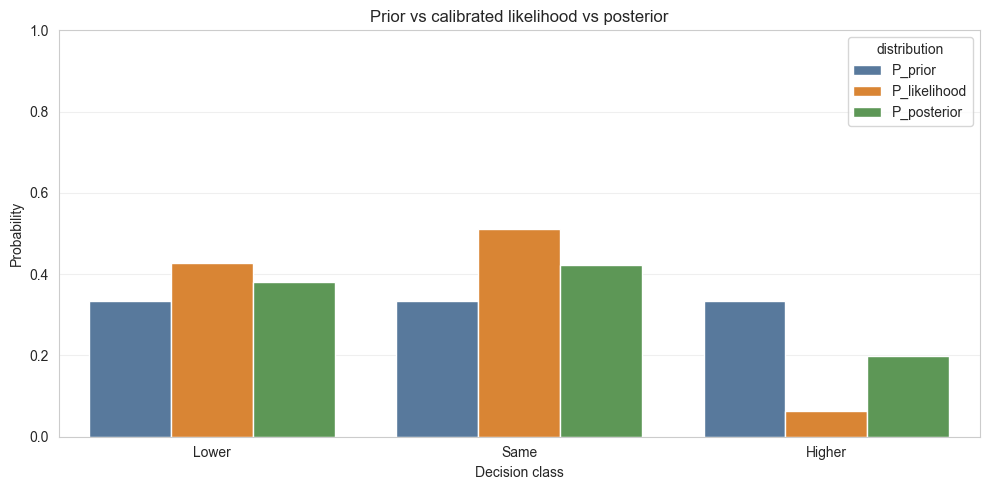

Bayesian output saved to /Users/echohuang/Documents/forecasting_fed_rate/analysis/bayesian_output.csv


,date,days_to_meeting,current_regime,prior_weight,likelihood_weight,p_prior_lower,p_prior_same,p_prior_higher,p_likelihood_lower,p_likelihood_same,p_likelihood_higher,p_posterior_lower,p_posterior_same,p_posterior_higher
0,2026-04-08,21,Easing,0.5000,0.5000,0.3333,0.3333,0.3333,0.4269,0.5104,0.0628,0.3801,0.4219,0.1981


In [6]:
plot_table = summary_table.melt(
    id_vars='class',
    value_vars=['P_prior', 'P_likelihood', 'P_posterior'],
    var_name='distribution',
    value_name='probability',
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=plot_table,
    x='class',
    y='probability',
    hue='distribution',
    palette=['#4c78a8', '#f58518', '#54a24b'],
    ax=ax,
)
ax.set_title('Prior vs calibrated likelihood vs posterior')
ax.set_xlabel('Decision class')
ax.set_ylabel('Probability')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

output_row = pd.DataFrame([{
    'date': today.date().isoformat(),
    'days_to_meeting': days_to_meeting,
    'current_regime': current_regime,
    'prior_weight': prior_weight,
    'likelihood_weight': likelihood_weight,
    'p_prior_lower': prior_vector[0],
    'p_prior_same': prior_vector[1],
    'p_prior_higher': prior_vector[2],
    'p_likelihood_lower': likelihood_vector[0],
    'p_likelihood_same': likelihood_vector[1],
    'p_likelihood_higher': likelihood_vector[2],
    'p_posterior_lower': posterior_vector[0],
    'p_posterior_same': posterior_vector[1],
    'p_posterior_higher': posterior_vector[2],
}])

bayesian_out = Path('bayesian_output.csv')
output_row.to_csv(bayesian_out, index=False)
print(f'Bayesian output saved to {bayesian_out.resolve()}')
display(output_row)
